In [1]:
%matplotlib inline

In [2]:
# MODIFY to generate figures for that number of active sources
nnz = 5

In [3]:
import os 

# please update your paths
import mne

os.environ['SUBJECTS_DIR'] = '/home/anujanegi/tj/bdsg/freesurfer/subjects'
PATH_TO_ESTIMATES = "bsi_zoo/tests/data/estimates/fixed/nnz_%d"%nnz
PATH_TO_SAVE_FIGURES = "figures/nnz_%d"%nnz
SOLVER_NAMES = ['iterative_L1', 'iterative_L2', 'iterative_sqrt', 'iterative_L1_typeII', 'iterative_L2_typeII', 'gamma_map']
SUBJECTS = ["CC120166", "CC120264", "CC120309", "CC120313"]

mne.viz.set_3d_backend('pyvista')
HEMISPHERES = ["lh", "rh"]
# ['iterative_L1' , 'iterative_L2', 'iterative_sqrt', 'iterative_L1_typeII', 'iterative_L2_typeII', 'gamma_map']

if not os.path.exists(PATH_TO_SAVE_FIGURES):
    os.makedirs(PATH_TO_SAVE_FIGURES)

Using pyvista 3d backend.



/home/anujanegi/anaconda3/envs/mne/lib/python3.9/site-packages/mne/viz/backends/_pyvista.py:40: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')
/home/anujanegi/anaconda3/envs/mne/lib/python3.9/site-packages/mne/viz/backends/_pyvista.py:40: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')


In [4]:
def metrics(fwd, stc, stc_hat):
    vertices = []
    vertices.append(fwd["src"][0]["vertno"])
    vertices.append(fwd["src"][1]["vertno"])

    # Reverse the effect of make_sparse_stc
    # stc now contains a sparse matrix with a lot of zero rows and few non-zero
    # rows containing the activations

    stc.expand(vertices)
    stc_hat.expand(vertices)

    est_activations = np.abs(stc_hat.data).sum(axis=-1)
    true_activations = np.abs(stc.data).sum(axis=-1)

    estimated_as = est_activations != 0
    true_as = true_activations != 0

    recall = recall_score(true_as, estimated_as, zero_division=0)
    emd = wasserstein_distance(est_activations, true_activations) #TODO: info about geometry
    hammingloss = hamming_loss(true_as, estimated_as)
    jaccard = jaccard_score(true_as, estimated_as, zero_division=0) #TODO: verify

    return recall, emd, hammingloss, jaccard

In [5]:
def add_margin(nonwhite_col, margin=5):
    margin_nonwhite_col = nonwhite_col.copy()
    for i in range(len(nonwhite_col)):
        if nonwhite_col[i] == True and nonwhite_col[i - 1] == False:
            margin_nonwhite_col[i - (1 + margin) : i - 1] = True
        elif nonwhite_col[i] == False and nonwhite_col[i - 1] == True:
            margin_nonwhite_col[i : i + margin] = True
    return margin_nonwhite_col

In [6]:
def add_foci_to_brain_surface(brain, stc, ax, color, label):
    for i_hemi, hemi in enumerate(HEMISPHERES):
        surface_coords = brain.geo[hemi].coords
        hemi_data = stc.lh_data if hemi == "lh" else stc.rh_data
        
        for k in range(len(stc.vertices[i_hemi])):
            activation_idx = stc.vertices[i_hemi][k]
            foci_coords = surface_coords[activation_idx]

            # In milliseconds
            (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
            brain.add_foci(foci_coords, hemi=hemi, color=line.get_color(), alpha=0.5, name=label)

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (nAm)")
    ax.legend()

In [5]:
from bsi_zoo.config import get_leadfield_path
subject = SUBJECTS[0]
from bsi_zoo.data_generator import get_data
from bsi_zoo.estimators import eloreta, iterative_L1, gamma_map
from mne.inverse_sparse.mxne_inverse import _make_sparse_stc
from mne import read_forward_solution
import numpy as np

y, L, x, cov, _ = get_data(seed=22, nnz=nnz, n_times=10
                           , cov_type="diag", orientation_type="fixed", alpha=0.7, path_to_leadfield=get_leadfield_path(subject, type="fixed"))


In [8]:
[0.0001, 0.01, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]
estimator_alphas_II = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]


[0.0001, 0.01, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]

In [ ]:
for eloreta

### TNL .3

# true - 0.2, 
alpha=.00001
EMD: 0.053394436144769346
reconstructed_noise: 0.10355713761023558

# true - 0.1, 
alpha=.0003
EMD: 0.052962287018743684
reconstructed_noise: 0.20707996546431942

# true,
alpha=.02 
EMD: 0.048753658947964816
reconstructed_noise: 0.3054756651212348


# true + 0.1, 
alpha=.7
EMD: 0.04311814061520803
reconstructed_noise: 0.4034334023778557

# true + 0.2
alpha=3
EMD: 0.04286022738653591
reconstructed_noise: 0.5165606095676858


# # for eloreta old before nov

# ### TNL .3

# # true - 0.2, 
# alpha=.00001
# EMD: 0.053394436144769346
# reconstructed_noise: 0.10355713761023558

# # true - 0.1, 
# alpha=.0003
# EMD: 0.052962287018743684
# reconstructed_noise: 0.20707996546431942

# # true,
# alpha=.02 
# EMD: 0.048753658947964816
# reconstructed_noise: 0.3054756651212348


# # true + 0.1, 
# alpha=.7
# EMD: 0.04311814061520803
# reconstructed_noise: 0.4034334023778557

# # true + 0.2
# alpha=3
# EMD: 0.04286022738653591
# reconstructed_noise: 0.5165606095676858

In [101]:
x_hat = eloreta(L,  y, alpha=0.0001, n_orient=1)

fwd_fname = "bsi_zoo/tests/data/%s-fwd.fif"%subject
fwd = read_forward_solution(fwd_fname)
fwd = mne.convert_forward_solution(fwd, force_fixed=True)
active_set = np.linalg.norm(x, axis=1) != 0

 # check if no vertices are estimated
temp = np.linalg.norm(x_hat, axis=1)
if len(np.unique(temp))==1:
    print("No vertices estimated!")

temp_ = np.partition(-temp, nnz)
# max_temp = temp
max_temp = -temp_[:300] #plot top 10 for dense method

# remove 0 from list incase less vertices than nnz were estimated
max_temp = np.delete(max_temp, np.where(max_temp==0.))
active_set_hat = np.array(list(map(max_temp.__contains__, temp)))


stc = _make_sparse_stc(
    x[active_set], active_set, fwd, tmin=1, tstep=1
)  # ground truth
stc_hat = _make_sparse_stc(
    x_hat[active_set_hat], active_set_hat, fwd, tmin=1, tstep=1
)  # estimate

source_space = mne.read_source_spaces(fwd_fname)

stc_fs = mne.compute_source_morph(
    stc_hat, subject, "fsaverage", '/home/anujanegi/tj/bdsg/freesurfer/subjects'
).apply(stc_hat)

#              # Plot the STC, get the brain image, crop it:
# brain = stc_fs.plot(
#     # views=["lat", "medial"],
#     # hemi="split" if len(HEMISPHERES) > 1 else HEMISPHERES[0],
#     hemi="both",
#     size=(500, 800),
#     background="w",
#     # clim="auto",
#     colorbar=False,
#     colormap="inferno",
#     time_viewer=True,
#     show_traces=True,
#     surface="flat",
#     cortex="classic",
#     # volume_options=dict(resolution=1),
#     view_layout="horizontal",
# )

# for i_hemi, hemi in enumerate(['lh', 'rh']):
#     surface_coords = brain.geo[hemi].coords
#     hemi_data = stc.lh_data if hemi == "lh" else stc.rh_data
#     for k in range(len(stc.vertices[i_hemi])):
#         activation_idx = stc.vertices[i_hemi][k]
#         foci_coords = surface_coords[activation_idx]

#         # In milliseconds
#         # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
#         brain.add_foci(foci_coords, hemi=hemi, color='red', alpha=1)

# for i_hemi, hemi in enumerate(['lh', 'rh']):
#     surface_coords = brain.geo[hemi].coords
#     hemi_data = stc_hat.lh_data if hemi == "lh" else stc_hat.rh_data
#     for k in range(len(stc_hat.vertices[i_hemi])):
#         activation_idx = stc_hat.vertices[i_hemi][k]
#         foci_coords = surface_coords[activation_idx]

#         # In milliseconds
#         # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
#         brain.add_foci(foci_coords, hemi=hemi, color='blue', alpha=.9)

# screenshot = brain.screenshot()

# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.axes_grid1 import make_axes_locatable, ImageGrid, inset_locator

# import mne
# nonwhite_pix = (screenshot != 255).any(-1)
# nonwhite_row = nonwhite_pix.any(1)
# nonwhite_col = nonwhite_pix.any(0)
# cropped_screenshot = screenshot[nonwhite_row][:, nonwhite_col]

# # plot screenshot
# fig, ax = plt.subplots(figsize=(10, 10))
# # ax.imshow(screenshot)
# # no ticks and graph borders
# ax.set_xticks([])
# ax.set_yticks([])
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["bottom"].set_visible(False)
# ax.spines["left"].set_visible(False)

# ax.imshow(cropped_screenshot)
# # save in high quality with transparent background
# # fig.savefig("./bsi_zoo/data/figs/brain.png", dpi=300, bbox_inches="tight", transparent=True)
# # fig.savefig("./bsi_zoo/data/figs/recon source.png", dpi=300, bbox_inches="tight", transparent=True)


# from bsi_zoo.metrics import emd, reconstructed_noise
# e = emd(x, x_hat, 'fixed', subject)
# print('EMD:', e)

r = reconstructed_noise(x, x_hat, 'fixed', y=y, L=L)
print('reconstructed_noise:', r)


Reading forward solution from bsi_zoo/tests/data/CC120166-fwd.fif...
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523) not available
    Read MEG forward solution (5123 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Changing to fixed-orientation forward solution with surface-based source orientations...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
reconstructed_noise: 0.18465463206084398


Reading forward solution from bsi_zoo/tests/data/CC120166-fwd.fif...
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523) not available
    Read MEG forward solution (5123 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Changing to fixed-orientation forward solution with surface-based source orientations...
    [done]
EMD: 0.053391181294270874
reconstructed_noise: 0.18465463206084398


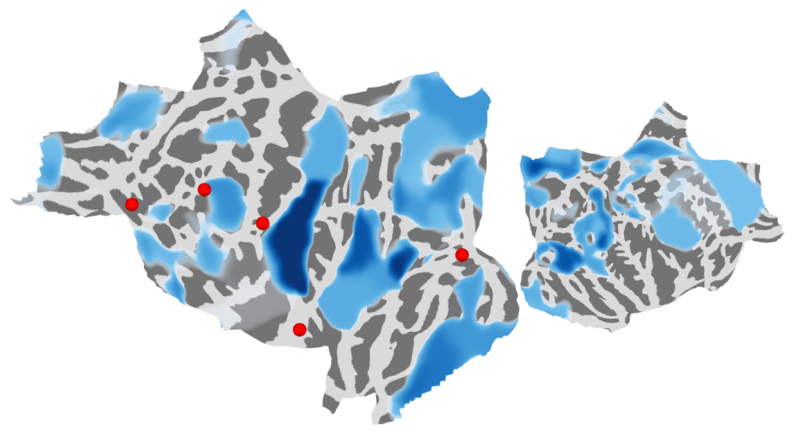

In [102]:

# Average over time
stc_avg = stc_fs.mean()

peak_time = stc_fs.get_peak(vert_as_index=True, time_as_index=True)
stc_peak = stc_fs.copy().crop(peak_time[1], peak_time[1])

data_range = stc_avg.data  # or stc.data for the whole source estimate

# Define thresholds based on percentiles or standard deviations
lower_thresh = np.percentile(data_range, 49)  # 10th percentile as lower bound
mid_thresh = np.percentile(data_range, 74)  # Mean as midpoint
upper_thresh = np.percentile(data_range, 99)  # 99th percentile as upper bound


# Plot source estimate as a heatmap on the cortex
brain = stc_avg.plot(hemi='split', subject='fsaverage',
                     subjects_dir='/home/anujanegi/tj/bdsg/freesurfer/subjects', time_label='Average activation',
                     colormap='Blues', clim=dict(kind='value', lims=[lower_thresh, mid_thresh, upper_thresh]), smoothing_steps=5, surface='flat', size=(500, 800), background="w", colorbar=False, time_viewer=False,
    show_traces=False,)

for i_hemi, hemi in enumerate(['lh', 'rh']):
    surface_coords = brain.geo[hemi].coords
    hemi_data = stc.lh_data if hemi == "lh" else stc.rh_data
    for k in range(len(stc.vertices[i_hemi])):
        activation_idx = stc.vertices[i_hemi][k]
        foci_coords = surface_coords[activation_idx]

        # In milliseconds
        # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
        brain.add_foci(foci_coords, hemi=hemi, color='red', alpha=1)

# for i_hemi, hemi in enumerate(['lh', 'rh']):
#     surface_coords = brain.geo[hemi].coords
#     hemi_data = stc_hat.lh_data if hemi == "lh" else stc_hat.rh_data
#     for k in range(len(stc_hat.vertices[i_hemi])):
        
#         activation_idx = stc_hat.vertices[i_hemi][k]
#         foci_coords = surface_coords[activation_idx]

#         # In milliseconds
#         # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
#         brain.add_foci(foci_coords, hemi=hemi, color='blue', alpha=.9)

screenshot = brain.screenshot()


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable, ImageGrid, inset_locator

import mne
nonwhite_pix = (screenshot != 255).any(-1)
nonwhite_row = nonwhite_pix.any(1)
nonwhite_col = nonwhite_pix.any(0)
cropped_screenshot = screenshot[nonwhite_row][:, nonwhite_col]

# plot screenshot
fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(screenshot)
# no ticks and graph borders
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.imshow(cropped_screenshot)
# save in high quality with transparent background
# fig.savefig("./bsi_zoo/data/figs/brain.png", dpi=300, bbox_inches="tight", transparent=True)
# fig.savefig("./bsi_zoo/data/figs/recon source.png", dpi=300, bbox_inches="tight", transparent=True)

from bsi_zoo.metrics import emd, reconstructed_noise
e = emd(x, x_hat, 'fixed', subject)
print('EMD:', e)

r = reconstructed_noise(x, x_hat, 'fixed', y=y, L=L)
print('reconstructed_noise:', r)

In [109]:
import numpy as np

# Get the data range from the source estimate (peak or full data)
data_range = stc_avg.data  # or stc.data for the whole source estimate

# Define thresholds based on percentiles or standard deviations
lower_thresh = np.percentile(data_range, 49)  # 10th percentile as lower bound
mid_thresh = np.percentile(data_range, 74)  # Mean as midpoint
upper_thresh = np.percentile(data_range, 99)  # 99th percentile as upper bound

# # Plot with auto-calculated thresholds
# brain = stc_peak.plot(
#     hemi='both',
#     views='lat',
#     subject=subject,
#     subjects_dir=subjects_dir,
#     time_label=f'Peak activation at {stc_peak.times[0]:.3f} s',
#     colormap='hot',
#     clim=dict(kind='value', lims=[lower_thresh, mid_thresh, upper_thresh]),
#     smoothing_steps=5
# )
lower_thresh, mid_thresh, upper_thresh


(0.0012042809978234101, 0.021923798817663577, 0.12719774096581207)

In [ ]:
# for gamma map

### TNL .3

# true - 0.2, 
alpha=.0003


# true - 0.1, iter 20
alpha=0.00002
EMD: 0.05135846874567991
reconstructed_noise: 0.24984908863339395

# true,
alpha=0.000028 iter 100
EMD: 0.03743358287784861
reconstructed_noise: 0.3021198447240613

# true + 0.1, 
alpha=0.00024 iter 100
EMD: 0.010839995615006115
reconstructed_noise: 0.40171399473426483

# true + 0.2
alpha=0.00054 iter 100
EMD: 0.0159943331133686
reconstructed_noise: 0.5009840733320554


In [ ]:
0.000007
RNL 0.27

In [28]:
x_hat = gamma_map(L,  y, alpha=0.00054, n_orient=1, max_iter=100)

fwd_fname = "bsi_zoo/tests/data/%s-fwd.fif"%subject
fwd = read_forward_solution(fwd_fname)
fwd = mne.convert_forward_solution(fwd, force_fixed=True)
active_set = np.linalg.norm(x, axis=1) != 0

 # check if no vertices are estimated
temp = np.linalg.norm(x_hat, axis=1)
if len(np.unique(temp))==1:
    print("No vertices estimated!")

temp_ = np.partition(-temp, nnz)
max_temp = -temp_[:20]

# remove 0 from list incase less vertices than nnz were estimated
max_temp = np.delete(max_temp, np.where(max_temp==0.))
active_set_hat = np.array(list(map(max_temp.__contains__, temp)))


stc = _make_sparse_stc(
    x[active_set], active_set, fwd, tmin=1, tstep=1
)  # ground truth
stc_hat = _make_sparse_stc(
    x_hat[active_set_hat], active_set_hat, fwd, tmin=1, tstep=1
)  # estimate

source_space = mne.read_source_spaces(fwd_fname)


stc_fs = mne.compute_source_morph(
    stc_hat, subject, "fsaverage", '/home/anujanegi/tj/bdsg/freesurfer/subjects'
).apply(stc_hat)            

# stc_fs = mne.compute_source_morph(
#     stc, subject, "fsaverage", '/home/anujanegi/tj/bdsg/freesurfer/subjects'
# ).apply(stc)
            
#              # Plot the STC, get the brain image, crop it:
# brain = stc_fs.plot(
#     # views=["lat", "medial"],
#     # hemi="split" if len(HEMISPHERES) > 1 else HEMISPHERES[0],
#     hemi="both",
#     size=(500, 800),
#     background="w",
#     # clim="auto",
#     colorbar=False,
#     # colormap="inferno",
#     time_viewer=False,
#     show_traces=False,
#     surface="flat",
#     cortex="classic",
#     # volume_options=dict(resolution=1),
#     view_layout="horizontal",
# )

# for i_hemi, hemi in enumerate(['lh', 'rh']):
#     surface_coords = brain.geo[hemi].coords
#     hemi_data = stc.lh_data if hemi == "lh" else stc.rh_data
#     for k in range(len(stc.vertices[i_hemi])):
#         activation_idx = stc.vertices[i_hemi][k]
#         foci_coords = surface_coords[activation_idx]

#         # In milliseconds
#         # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
#         brain.add_foci(foci_coords, hemi=hemi, color='red', alpha=1)

# for i_hemi, hemi in enumerate(['lh', 'rh']):
#     surface_coords = brain.geo[hemi].coords
#     hemi_data = stc_hat.lh_data if hemi == "lh" else stc_hat.rh_data
#     for k in range(len(stc_hat.vertices[i_hemi])):
#         activation_idx = stc_hat.vertices[i_hemi][k]
#         foci_coords = surface_coords[activation_idx]

#         # In milliseconds
#         # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
#         brain.add_foci(foci_coords, hemi=hemi, color='blue', alpha=.9)

# screenshot = brain.screenshot()

# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.axes_grid1 import make_axes_locatable, ImageGrid, inset_locator

# import mne
# nonwhite_pix = (screenshot != 255).any(-1)
# nonwhite_row = nonwhite_pix.any(1)
# nonwhite_col = nonwhite_pix.any(0)
# cropped_screenshot = screenshot[nonwhite_row][:, nonwhite_col]

# # plot screenshot
# fig, ax = plt.subplots(figsize=(10, 10))
# # ax.imshow(screenshot)
# # no ticks and graph borders
# ax.set_xticks([])
# ax.set_yticks([])
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["bottom"].set_visible(False)
# ax.spines["left"].set_visible(False)

# ax.imshow(cropped_screenshot)
# # save in high quality with transparent background
# # fig.savefig("./bsi_zoo/data/figs/brain.png", dpi=300, bbox_inches="tight", transparent=True)
# # fig.savefig("./bsi_zoo/data/figs/recon source.png", dpi=300, bbox_inches="tight", transparent=True)


# from bsi_zoo.metrics import emd, reconstructed_noise
# e = emd(x, x_hat, 'fixed', subject)
# print('EMD:', e)

# r = reconstructed_noise(x, x_hat, 'fixed', y=y, L=L)
# print('reconstructed_noise:', r)


Iteration: 0	 active set size: 4686	 convergence: 4.799e-01
Iteration: 14	 active set size: 4685	 convergence: 1.041e-01
Iteration: 15	 active set size: 4681	 convergence: 9.530e-02
Iteration: 16	 active set size: 4670	 convergence: 8.899e-02
Iteration: 17	 active set size: 4651	 convergence: 8.287e-02
Iteration: 18	 active set size: 4608	 convergence: 7.651e-02
Iteration: 19	 active set size: 4527	 convergence: 7.153e-02
Iteration: 20	 active set size: 4421	 convergence: 6.844e-02
Iteration: 21	 active set size: 4277	 convergence: 6.569e-02
Iteration: 22	 active set size: 4118	 convergence: 6.334e-02
Iteration: 23	 active set size: 3905	 convergence: 6.070e-02
Iteration: 24	 active set size: 3700	 convergence: 5.793e-02
Iteration: 25	 active set size: 3514	 convergence: 5.525e-02
Iteration: 26	 active set size: 3327	 convergence: 5.247e-02
Iteration: 27	 active set size: 3139	 convergence: 4.964e-02
Iteration: 28	 active set size: 2979	 convergence: 4.680e-02
Iteration: 29	 active set

/home/anujanegi/tj/bdsg/BSI-Zoo/bsi_zoo/estimators.py:398: RuntimeWarning: 
Convergence NOT reached !

  warn("\nConvergence NOT reached !\n")


    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Changing to fixed-orientation forward solution with surface-based source orientations...
    [done]
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read


/tmp/ipykernel_22645/2103247322.py:31: RuntimeWarning: 4855/157720 vertices not included in smoothing, consider increasing the number of steps
  stc_fs = mne.compute_source_morph(


In [31]:

# Average over time
stc_avg = stc_fs.mean()

peak_time = stc_fs.get_peak(vert_as_index=True, time_as_index=True)
stc_peak = stc_fs.copy().crop(peak_time[1], peak_time[1])

data_range = stc_avg.data  # or stc.data for the whole source estimate

# Define thresholds based on percentiles or standard deviations
lower_thresh = np.percentile(data_range, 49)  # 10th percentile as lower bound
mid_thresh = np.percentile(data_range, 74)  # Mean as midpoint
upper_thresh = np.percentile(data_range, 99)  # 99th percentile as upper bound


# Plot source estimate as a heatmap on the cortex
brain = stc_fs.plot(hemi='split', subject='fsaverage',
                     subjects_dir='/home/anujanegi/tj/bdsg/freesurfer/subjects', time_label='Average activation',
                     colormap='Blues', smoothing_steps=1, surface='flat', size=(500, 800), background="w", colorbar=False, time_viewer=False,
    show_traces=False,)

# brain = stc_fs.plot(
#     # views=["lat", "medial"],
#     # hemi="split" if len(HEMISPHERES) > 1 else HEMISPHERES[0],
#     hemi="both",
#     size=(500, 800),
#     background="w",
#     # clim="auto",
#     colorbar=False,
#     # colormap="inferno",
#     time_viewer=False,
#     show_traces=False,
#     surface="flat",
#     cortex="classic",
#     # volume_options=dict(resolution=1),
#     view_layout="horizontal",
# )


for i_hemi, hemi in enumerate(['lh', 'rh']):
    surface_coords = brain.geo[hemi].coords
    hemi_data = stc.lh_data if hemi == "lh" else stc.rh_data
    for k in range(len(stc.vertices[i_hemi])):
        activation_idx = stc.vertices[i_hemi][k]
        foci_coords = surface_coords[activation_idx]

        # In milliseconds
        # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
        brain.add_foci(foci_coords, hemi=hemi, color='red', alpha=1)

# for i_hemi, hemi in enumerate(['lh', 'rh']):
#     surface_coords = brain.geo[hemi].coords
#     hemi_data = stc_hat.lh_data if hemi == "lh" else stc_hat.rh_data
#     for k in range(len(stc_hat.vertices[i_hemi])):
        
#         activation_idx = stc_hat.vertices[i_hemi][k]
#         foci_coords = surface_coords[activation_idx]

#         # In milliseconds
#         # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
#         brain.add_foci(foci_coords, hemi=hemi, color='Blue', alpha=.9)

# screenshot = brain.screenshot()
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, get
colormap = get_cmap("Blues")  # Use "Blues" for reconstructed data
norm = Normalize(vmin=np.min(np.abs(stc_hat.data)), vmax=np.max(np.abs(stc_hat.data)))

for i_hemi, hemi in enumerate(["lh", "rh"]):
    # Get hemisphere-specific data
    surface_coords = brain.geo[hemi].coords
    hemi_data = stc_hat.lh_data if hemi == "lh" else stc_hat.rh_data

    for k in range(len(stc_hat.vertices[i_hemi])):
        # Get vertex index and activation strength
        activation_idx = stc_hat.vertices[i_hemi][k]
        strength = np.abs(hemi_data[k])  # Get the amplitude (strength)

        # Get focus coordinates and color based on strength
        foci_coords = surface_coords[activation_idx]
        color = colormap(norm(max(strength)))  # Map strength to color using colormap
        color = tuple(map(float, color[:3]))

        # Add foci with computed color
        brain.add_foci(foci_coords, hemi=hemi, color=color, alpha=0.9)



import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable, ImageGrid, inset_locator

import mne
nonwhite_pix = (screenshot != 255).any(-1)
nonwhite_row = nonwhite_pix.any(1)
nonwhite_col = nonwhite_pix.any(0)
cropped_screenshot = screenshot[nonwhite_row][:, nonwhite_col]

# plot screenshot
fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(screenshot)
# no ticks and graph borders
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.imshow(cropped_screenshot)
# save in high quality with transparent background
# fig.savefig("./bsi_zoo/data/figs/brain.png", dpi=300, bbox_inches="tight", transparent=True)
# fig.savefig("./bsi_zoo/data/figs/recon source.png", dpi=300, bbox_inches="tight", transparent=True)

from bsi_zoo.metrics import emd, reconstructed_noise
e = emd(x, x_hat, 'fixed', subject)
print('EMD:', e)

r = reconstructed_noise(x, x_hat, 'fixed', y=y, L=L)
print('reconstructed_noise:', r)

Using control points [0.03855327 0.09192635 1.16489971]


NameError: name 'screenshot' is not defined

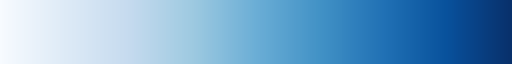

In [33]:
colormap

In [40]:
def sub_cmap(cmap, vmin, vmax):
    return lambda v: cmap(vmin + (vmax - vmin) * v)

cmap = get_cmap('Blues') # Get your favorite cmap
new_cmap = sub_cmap(cmap, 0.2, 0.9)
new_cmap


<function __main__.sub_cmap.<locals>.<lambda>(v)>

In [37]:
!pip install cmasher

     |████████████████████████████████| 533 kB 539 kB/s eta 0:00:01
     |████████████████████████████████| 8.3 MB 2.4 MB/s eta 0:00:01
     |████████████████████████████████| 19.5 MB 797 kB/s eta 0:00:01
     |████████████████████████████████| 321 kB 2.6 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.20.3
    Uninstalling numpy-1.20.3:
      Successfully uninstalled numpy-1.20.3
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.4.2
    Uninstalling matplotlib-3.4.2:
      Successfully uninstalled matplotlib-3.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.6.3 requires numpy<1.23.0,>=1.16.5, but you have numpy 2.0.2 which is incompatible.


In [ ]:
x_hat = iterative_L1(L,  y, alpha=0.0001, n_orient=1)

fwd_fname = "bsi_zoo/tests/data/%s-fwd.fif"%subject
fwd = read_forward_solution(fwd_fname)
fwd = mne.convert_forward_solution(fwd, force_fixed=True)
active_set = np.linalg.norm(x, axis=1) != 0

 # check if no vertices are estimated
temp = np.linalg.norm(x_hat, axis=1)
if len(np.unique(temp))==1:
    print("No vertices estimated!")

temp_ = np.partition(-temp, nnz)
max_temp = -temp_[:nnz] #get n(=nnz) max amplitudes 

# remove 0 from list incase less vertices than nnz were estimated
max_temp = np.delete(max_temp, np.where(max_temp==0.))
active_set_hat = np.array(list(map(max_temp.__contains__, temp)))

stc = _make_sparse_stc(
    x[active_set], active_set, fwd, tmin=1, tstep=1
)  # ground truth
stc_hat = _make_sparse_stc(
    x_hat[active_set_hat], active_set_hat, fwd, tmin=1, tstep=1
)  # estimate

source_space = mne.read_source_spaces(fwd_fname)
            
             # Plot the STC, get the brain image, crop it:
brain = stc.plot(
    views=["lat", "medial"],
    # hemi="split" if len(HEMISPHERES) > 1 else HEMISPHERES[0],
    hemi="lh",
    size=(500, 800),
    background="w",
    # clim="auto",
    colorbar=False,
    colormap="inferno",
    time_viewer=False,
    show_traces=False,
    surface="inflated",
    cortex="classic",
    # volume_options=dict(resolution=1),
    view_layout="horizontal",
)

for i_hemi, hemi in enumerate(['lh']):
    surface_coords = brain.geo[hemi].coords
    hemi_data = stc.lh_data if hemi == "lh" else stc.rh_data
    for k in range(len(stc.vertices[i_hemi])):
        activation_idx = stc.vertices[i_hemi][k]
        foci_coords = surface_coords[activation_idx]

        # In milliseconds
        # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
        brain.add_foci(foci_coords, hemi=hemi, color='red', alpha=1)

for i_hemi, hemi in enumerate(['lh']):
    surface_coords = brain.geo[hemi].coords
    hemi_data = stc_hat.lh_data if hemi == "lh" else stc_hat.rh_data
    for k in range(len(stc_hat.vertices[i_hemi])):
        activation_idx = stc_hat.vertices[i_hemi][k]
        foci_coords = surface_coords[activation_idx]

        # In milliseconds
        # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
        brain.add_foci(foci_coords, hemi=hemi, color='blue', alpha=.9)

screenshot = brain.screenshot()

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable, ImageGrid, inset_locator

import mne
nonwhite_pix = (screenshot != 255).any(-1)
nonwhite_row = nonwhite_pix.any(1)
nonwhite_col = nonwhite_pix.any(0)
cropped_screenshot = screenshot[nonwhite_row][:, nonwhite_col]

# plot screenshot
fig, ax = plt.subplots(figsize=(10, 20))
# ax.imshow(screenshot)
# no ticks and graph borders
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.imshow(screenshot)
# save in high quality with transparent background
# fig.savefig("./bsi_zoo/data/figs/brain.png", dpi=300, bbox_inches="tight", transparent=True)
# fig.savefig("./bsi_zoo/data/figs/recon source.png", dpi=300, bbox_inches="tight", transparent=True)

In [ ]:
x_hat = eloreta(L,  y, alpha=0.01, n_orient=1)

fwd_fname = "bsi_zoo/tests/data/%s-fwd.fif"%subject
fwd = read_forward_solution(fwd_fname)
fwd = mne.convert_forward_solution(fwd, force_fixed=True)
active_set = np.linalg.norm(x, axis=1) != 0

 # check if no vertices are estimated
temp = np.linalg.norm(x_hat, axis=1)
if len(np.unique(temp))==1:
    print("No vertices estimated!")

temp_ = np.partition(-temp, nnz)
max_temp = -temp_[:10] #plot top 10 for dense method

# remove 0 from list incase less vertices than nnz were estimated
max_temp = np.delete(max_temp, np.where(max_temp==0.))
active_set_hat = np.array(list(map(max_temp.__contains__, temp)))


stc = _make_sparse_stc(
    x[active_set], active_set, fwd, tmin=1, tstep=1
)  # ground truth
stc_hat = _make_sparse_stc(
    x_hat[active_set_hat], active_set_hat, fwd, tmin=1, tstep=1
)  # estimate

source_space = mne.read_source_spaces(fwd_fname)
            
             # Plot the STC, get the brain image, crop it:
brain = stc.plot(
    views=["lat", "medial"],
    # hemi="split" if len(HEMISPHERES) > 1 else HEMISPHERES[0],
    hemi="lh",
    size=(500, 800),
    background="w",
    # clim="auto",
    colorbar=False,
    colormap="inferno",
    time_viewer=False,
    show_traces=False,
    surface="inflated",
    cortex="classic",
    # volume_options=dict(resolution=1),
    view_layout="horizontal",
)

for i_hemi, hemi in enumerate(['lh']):
    surface_coords = brain.geo[hemi].coords
    hemi_data = stc.lh_data if hemi == "lh" else stc.rh_data
    for k in range(len(stc.vertices[i_hemi])):
        activation_idx = stc.vertices[i_hemi][k]
        foci_coords = surface_coords[activation_idx]

        # In milliseconds
        # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
        brain.add_foci(foci_coords, hemi=hemi, color='red', alpha=1)

for i_hemi, hemi in enumerate(['lh']):
    surface_coords = brain.geo[hemi].coords
    hemi_data = stc_hat.lh_data if hemi == "lh" else stc_hat.rh_data
    for k in range(len(stc_hat.vertices[i_hemi])):
        activation_idx = stc_hat.vertices[i_hemi][k]
        foci_coords = surface_coords[activation_idx]

        # In milliseconds
        # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
        brain.add_foci(foci_coords, hemi=hemi, color='blue', alpha=.9)

screenshot = brain.screenshot()

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable, ImageGrid, inset_locator

import mne
nonwhite_pix = (screenshot != 255).any(-1)
nonwhite_row = nonwhite_pix.any(1)
nonwhite_col = nonwhite_pix.any(0)
cropped_screenshot = screenshot[nonwhite_row][:, nonwhite_col]

# plot screenshot
fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(screenshot)
# no ticks and graph borders
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.imshow(cropped_screenshot)
# save in high quality with transparent background
# fig.savefig("./bsi_zoo/data/figs/brain.png", dpi=300, bbox_inches="tight", transparent=True)
# fig.savefig("./bsi_zoo/data/figs/recon source.png", dpi=300, bbox_inches="tight", transparent=True)

In [ ]:
x_hat = gamma_map(L,  y, alpha=0.01, n_orient=1, max_iter=16)

fwd_fname = "bsi_zoo/tests/data/%s-fwd.fif"%subject
fwd = read_forward_solution(fwd_fname)
fwd = mne.convert_forward_solution(fwd, force_fixed=True)
active_set = np.linalg.norm(x, axis=1) != 0

 # check if no vertices are estimated
temp = np.linalg.norm(x_hat, axis=1)
if len(np.unique(temp))==1:
    print("No vertices estimated!")

temp_ = np.partition(-temp, nnz)
max_temp = -temp_[:nnz]

# remove 0 from list incase less vertices than nnz were estimated
max_temp = np.delete(max_temp, np.where(max_temp==0.))
active_set_hat = np.array(list(map(max_temp.__contains__, temp)))


stc = _make_sparse_stc(
    x[active_set], active_set, fwd, tmin=1, tstep=1
)  # ground truth
stc_hat = _make_sparse_stc(
    x_hat[active_set_hat], active_set_hat, fwd, tmin=1, tstep=1
)  # estimate

source_space = mne.read_source_spaces(fwd_fname)
            
             # Plot the STC, get the brain image, crop it:
brain = stc.plot(
    views=["lat", "medial"],
    # hemi="split" if len(HEMISPHERES) > 1 else HEMISPHERES[0],
    hemi="lh",
    size=(500, 800),
    background="w",
    # clim="auto",
    colorbar=False,
    colormap="inferno",
    time_viewer=False,
    show_traces=False,
    surface="inflated",
    cortex="classic",
    # volume_options=dict(resolution=1),
    view_layout="horizontal",
)

for i_hemi, hemi in enumerate(['lh']):
    surface_coords = brain.geo[hemi].coords
    hemi_data = stc.lh_data if hemi == "lh" else stc.rh_data
    for k in range(len(stc.vertices[i_hemi])):
        activation_idx = stc.vertices[i_hemi][k]
        foci_coords = surface_coords[activation_idx]

        # In milliseconds
        # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
        
        brain.add_foci(foci_coords, hemi=hemi, color='blue', alpha=1)

for i_hemi, hemi in enumerate(['lh']):
    surface_coords = brain.geo[hemi].coords
    hemi_data = stc_hat.lh_data if hemi == "lh" else stc_hat.rh_data
    for k in range(len(stc_hat.vertices[i_hemi])):
        activation_idx = stc_hat.vertices[i_hemi][k]
        foci_coords = surface_coords[activation_idx]

        # In milliseconds
        # (line,) = ax.plot(stc.times * 1e3, 1e9 * hemi_data[k], '--', color=color, label=label)
        # brain.add_foci(foci_coords, hemi=hemi, color='blue', alpha=.9)

screenshot = brain.screenshot()

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable, ImageGrid, inset_locator

import mne
nonwhite_pix = (screenshot != 255).any(-1)
nonwhite_row = nonwhite_pix.any(1)
nonwhite_col = nonwhite_pix.any(0)
cropped_screenshot = screenshot[nonwhite_row][:, nonwhite_col]

# plot screenshot
fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(screenshot)
# no ticks and graph borders
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.imshow(cropped_screenshot)
# save in high quality with transparent background
# fig.savefig("./bsi_zoo/data/figs/brain.png", dpi=300, bbox_inches="tight", transparent=True)
# fig.savefig("./bsi_zoo/data/figs/recon source.png", dpi=300, bbox_inches="tight", transparent=True)

In [ ]:
# for free orientation the active set needs to diminised to the same shape of fixed
for subject in SUBJECTS:
    for solver in SOLVER_NAMES:
            print('-'*30)
            print('Making figures for %s method for subject %s...'%(solver.replace('_', ' '), subject))
            print('-'*30)
            
            x = np.load(os.path.join(PATH_TO_ESTIMATES, subject, solver+'_x_10.npy'))
            x_hat = np.load(os.path.join(PATH_TO_ESTIMATES, subject, solver+'_x_hat_10.npy'))

            fwd_fname = "bsi_zoo/tests/data/%s-fwd.fif"%subject
            fwd = read_forward_solution(fwd_fname)
            fwd = mne.convert_forward_solution(fwd, force_fixed=True)
            active_set = np.linalg.norm(x, axis=1) != 0
            
            # check if no vertices are estimated
            temp = np.linalg.norm(x_hat, axis=1)
            if len(np.unique(temp))==1:
                print("No vertices estimated!")
                continue
            
            temp_ = np.partition(-temp, nnz)
            max_temp = -temp_[:nnz] #get n(=nnz) max amplitudes 

            # remove 0 from list incase less vertices than nnz were estimated
            max_temp = np.delete(max_temp, np.where(max_temp==0.))
            active_set_hat = np.array(list(map(max_temp.__contains__, temp)))

            stc = _make_sparse_stc(
                x[active_set], active_set, fwd, tmin=1, tstep=1
            )  # ground truth
            stc_hat = _make_sparse_stc(
                x_hat[active_set_hat], active_set_hat, fwd, tmin=1, tstep=1
            )  # estimate
            
            source_space = mne.read_source_spaces(fwd_fname)
            
             # Plot the STC, get the brain image, crop it:
            brain = stc.plot(
                views=["lat", "med"],
                hemi="split" if len(HEMISPHERES) > 1 else HEMISPHERES[0],
                size=(500, 250),
                background="w",
                clim="auto",
                colorbar=False,
                colormap="inferno",
                time_viewer=False,
                show_traces=False,
                cortex="classic",
                volume_options=dict(resolution=1),
            )

            t = 10
            brain.set_time(t)

            fig = plt.figure(figsize=(5.5, 5.5))
            axes = [
                plt.subplot2grid((9, 1), (0, 0), rowspan=4),
                plt.subplot2grid((9, 1), (4, 0), rowspan=3),
                plt.subplot2grid((9, 1), (7, 0), rowspan=1), #hacky spacing
                plt.subplot2grid((9, 1), (8, 0), rowspan=1), #metrics
            ]

            add_foci_to_brain_surface(brain, stc, axes[1], color=(1, 0, 0), label='Ground Truth') #red
            add_foci_to_brain_surface(brain, stc_hat, axes[1], color=(0, 0, 1), label='Estimate') #blue

            screenshot = brain.screenshot()

            nonwhite_pix = (screenshot != 255).any(-1)
            nonwhite_row = nonwhite_pix.any(1)
            nonwhite_col = nonwhite_pix.any(0)

            # Add blank columns for margin
            nonwhite_col = add_margin(nonwhite_col)

            cropped_screenshot = screenshot[nonwhite_row][:, nonwhite_col]

            brain_idx = 0
            spacing_idx = 2 
            metrics_idx = 3

            axes[brain_idx].imshow(cropped_screenshot)
            axes[brain_idx].axis("off")
            
            axes[spacing_idx].axis("off")
            
            axes[metrics_idx].axis("off")
            # get metrics
            recall, emd, hammingloss, jaccard = metrics(fwd, stc, stc_hat)
            axes[metrics_idx].text(0.01, 0.5, 'Recall: %.2f  EMD: %.2e \nHamming Loss: %.2e  Jaccard Score: %.2e'%(recall, emd, hammingloss, jaccard),
                                   bbox=dict(facecolor='grey', alpha=0.1))
            
            fig.subplots_adjust(left=0.3, right=0.9, bottom=0.15, top=0.9, wspace=0.1,
                    hspace=0.2)

            fig.tight_layout()
            
            fig.savefig(os.path.join(PATH_TO_SAVE_FIGURES,'%s_%s.svg'%(solver, subject)))
            brain.close()

In [ ]:
#             plot_sparse_source_estimates(
#                 source_space, [stc, stc_hat], bgcolor=(1, 1, 1),
#                 fig_name=solver, opacity=0.1, colors=['r','b']
#             )

In [ ]:
#             brain = mne.viz.Brain(
#                 subject_id=subject,
#                 views=["lat", "med"],
# #                 views=["lat"],
#                 hemi="split" if len(HEMISPHERES) > 1 else HEMISPHERES[0],
#                 size=(500, 250),
#                 # size=(500, 500),
#                 background="w",
#                 surf='inflated',
#                 cortex="classic",
#                 show_toolbar=True
#             )

#             brain.add_text(34, 50,'dsd',name='dsdsadsadasdaa', row=0, col=0)
#             fig, ax = plt.subplots(1, 1)
#             add_foci_to_brain_surface(brain, stc, ax, color=(1, 0, 0), label='Ground Truth') #red
#             add_foci_to_brain_surface(brain, stc_hat, ax, color=(0, 0, 1), label='Estimate') #blue
#             fig.suptitle('Solver: %s'%solver)
#             plt.savefig(os.path.join(PATH_TO_SAVE_FIGURES, '%s_%s.jpg'%(solver, subject)))
#             brain.save_image(os.path.join(PATH_TO_SAVE_FIGURES, '%s_%s.png'%(solver, subject)))
#             brain.close()